In [2]:
import pandas as pd
import numpy as np

In [49]:
import matplotlib.pyplot as plt

In [50]:
import seaborn as sns

La siguiente base de datos, tiene en su contenido registros de facturacion de servicios medicos que una IPS, esta presentando a la entidad responsable de pago, para ella, la entidad pide:
1. que se validen que todos las columnas importantes tengan toda la información
2. que se genere un nueva columna en donde se cree un nuevo ID documento + fecha de prestacion.
3. que se verifiquen que no hayan registros duplicados con el mismo cups(que el servicio no este reportado mas de una ves en la misma fecha)


In [22]:
from google.colab import files
uploaded = files.upload()

Saving BASE EJEMPLO.xlsx to BASE EJEMPLO (1).xlsx


In [23]:
df = pd.read_excel("BASE EJEMPLO.xlsx")

df.head()

,Consecutivo,ARCHIVO ORIGEN,TIPO DE SERVICIO,NIT PRESTADOR,NUM FACTURA,TIPO NOTA,NUM NOTA,TIPO DOCUMENTO IDENTIFICACION USUARIO,NUM DOCUMENTO IDENTIFICACION USUARIO,TIPO USUARIO,...,COD DIAGNOSTICO RELACIONADO3,TIPO DIAGNOSTICO PRINCIPAL,TIPO DOCUMENTO IDENTIFICACION RECIEN NACIDO O PROFESIONAL,NUM DOCUMENTO IDENTIFICACION RECIEN NACIDO O PROFESIONAL,VALOR SERVICIO,CONCEPTO RECAUDO,VALOR PAGO MODERADOR,NUM FEV PAGO MODERADOR,CONSECUTIVO TIPO SERVICIO,VIA INGRESO SERVICIO SALUD
0,1,NaN,Consultas,900958564,9652734,NaN,NaN,CC,1000004123,1,...,NaN,1,CC,1127360962,0,2,5000,9632149.0,1,NaN
1,2,NaN,Consultas,900958564,9652734,NaN,NaN,CC,1000004780,1,...,NaN,1,CC,52962116,0,2,5000,9638096.0,1,NaN
2,3,NaN,Consultas,900958564,9652734,NaN,NaN,CC,1000005500,1,...,NaN,1,CC,1033774108,0,2,5000,9621768.0,1,NaN
3,4,NaN,Consultas,900958564,9652734,NaN,NaN,CC,1000006359,4,...,NaN,2,CC,52553419,0,5,0,NaN,1,NaN
4,5,NaN,Consultas,900958564,9652734,NaN,NaN,CC,1000018039,1,...,NaN,1,CC,52714588,0,5,0,NaN,1,NaN


In [24]:
df.shape

(999, 40)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 40 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   Consecutivo                                                999 non-null    int64         
 1   ARCHIVO ORIGEN                                             0 non-null      float64       
 2   TIPO DE SERVICIO                                           999 non-null    object        
 3   NIT PRESTADOR                                              999 non-null    int64         
 4   NUM FACTURA                                                999 non-null    int64         
 5   TIPO NOTA                                                  0 non-null      float64       
 6   NUM NOTA                                                   0 non-null      float64       
 7   TIPO DOCUMENTO IDENTIFICACION USUAR

Aqui notamos que hay columnas sin ningun dato, las cuales no se van a utilizar, por esto las eliminamos

In [26]:
df = df.dropna(axis=1, how='all')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 35 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   Consecutivo                                                999 non-null    int64         
 1   TIPO DE SERVICIO                                           999 non-null    object        
 2   NIT PRESTADOR                                              999 non-null    int64         
 3   NUM FACTURA                                                999 non-null    int64         
 4   TIPO DOCUMENTO IDENTIFICACION USUARIO                      999 non-null    object        
 5   NUM DOCUMENTO IDENTIFICACION USUARIO                       999 non-null    int64         
 6   TIPO USUARIO                                               999 non-null    int64         
 7   FECHA NACIMIENTO USUARIO           

aqui notamos que tiene varios diagnosticos relacionados, en este caso solo necesitamos el principal, de tal manera que eliminamos las columnas 24, 25, 26

In [29]:
df.drop(df.columns[[24, 25, 26]], axis=1, inplace=True)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 32 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   Consecutivo                                                999 non-null    int64         
 1   TIPO DE SERVICIO                                           999 non-null    object        
 2   NIT PRESTADOR                                              999 non-null    int64         
 3   NUM FACTURA                                                999 non-null    int64         
 4   TIPO DOCUMENTO IDENTIFICACION USUARIO                      999 non-null    object        
 5   NUM DOCUMENTO IDENTIFICACION USUARIO                       999 non-null    int64         
 6   TIPO USUARIO                                               999 non-null    int64         
 7   FECHA NACIMIENTO USUARIO           

Ahora antes de crear el nuevo ID que me pide la entidad, vamos accorregir un dato en la fecha dado que esta tiene tambien hora y al momento que vayamos a validar el tercer punto, el es que no hayan servicios de la misma fecha reportandos con el mismo cups, esto me puede generar que por la diferencia en hora, no identifique la duplcidad del servicio.

In [31]:
df["FECHA PRESTACION SERVICIO"] = df["FECHA PRESTACION SERVICIO"].dt.date

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 32 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   Consecutivo                                                999 non-null    int64         
 1   TIPO DE SERVICIO                                           999 non-null    object        
 2   NIT PRESTADOR                                              999 non-null    int64         
 3   NUM FACTURA                                                999 non-null    int64         
 4   TIPO DOCUMENTO IDENTIFICACION USUARIO                      999 non-null    object        
 5   NUM DOCUMENTO IDENTIFICACION USUARIO                       999 non-null    int64         
 6   TIPO USUARIO                                               999 non-null    int64         
 7   FECHA NACIMIENTO USUARIO           

In [34]:
df.shape

(999, 32)

Ahora si creamos una nueva columna

In [41]:
# Convertir la fecha a texto
df["FECHA_PRESTACION_TEXTO"] = df["FECHA PRESTACION SERVICIO"].astype(str)

In [42]:
# Crear la columna combinada
df["ID_FECHA"] = (
df["NUM DOCUMENTO IDENTIFICACION USUARIO"].astype(str)
+ "_"
+ df["FECHA_PRESTACION_TEXTO"]
)

In [44]:
df[["ID_FECHA"]].head()

,ID_FECHA
0,1000004123_2026-05-22
1,1000004780_2026-05-28
2,1000005500_2026-05-08
3,1000006359_2026-05-14
4,1000018039_2026-05-25


Para poder validar lo que me pide la entidad, crear otra nueva variable en donde este numero de documento, fecha y cups del servicio.

In [45]:
# combertimos la colunma a texo para que me permita unirla
df["COD CUMS CUPS"] = df["COD CUMS CUPS"].astype(str)

Ahora vamos a crear una llave unica, que nos permita hacer la validacion de los duplicados

In [46]:
df["LLAVE_UNICA"] = (
df["NUM DOCUMENTO IDENTIFICACION USUARIO"].astype(str)
+ "_"
+ df["FECHA PRESTACION SERVICIO"].astype(str)
+ "_"
+ df["COD CUMS CUPS"].astype(str)
)

In [47]:
df[["LLAVE_UNICA"]].head()

,LLAVE_UNICA
0,1000004123_2026-05-22_890301
1,1000004780_2026-05-28_890201
2,1000005500_2026-05-08_890301
3,1000006359_2026-05-14_890303
4,1000018039_2026-05-25_890201


In [48]:
# Ahora buscamos los duplicados
df[df["LLAVE_UNICA"].duplicated(keep=False)]


,Consecutivo,TIPO DE SERVICIO,NIT PRESTADOR,NUM FACTURA,TIPO DOCUMENTO IDENTIFICACION USUARIO,NUM DOCUMENTO IDENTIFICACION USUARIO,TIPO USUARIO,FECHA NACIMIENTO USUARIO,COD SEXO USUARIO,COD PAIS RESIDENCIA,...,TIPO DOCUMENTO IDENTIFICACION RECIEN NACIDO O PROFESIONAL,NUM DOCUMENTO IDENTIFICACION RECIEN NACIDO O PROFESIONAL,VALOR SERVICIO,CONCEPTO RECAUDO,VALOR PAGO MODERADOR,NUM FEV PAGO MODERADOR,CONSECUTIVO TIPO SERVICIO,FECHA_PRESTACION_TEXTO,ID_FECHA,LLAVE_UNICA
24,25,Consultas,900958564,9652734,CC,1000153857,1,2000-12-02,F,170,...,CC,49764172,0,5,0,NaN,2,2026-05-14,1000153857_2026-05-14,1000153857_2026-05-14_890205
26,27,Consultas,900958564,9652734,CC,1000153857,1,2000-12-02,F,170,...,CC,49764172,0,5,0,NaN,3,2026-05-14,1000153857_2026-05-14,1000153857_2026-05-14_890205
31,32,Consultas,900958564,9652734,CC,1000186260,1,1998-01-01,F,170,...,CC,80748346,0,5,0,NaN,2,2026-05-22,1000186260_2026-05-22,1000186260_2026-05-22_890205
33,34,Consultas,900958564,9652734,CC,1000186260,1,1998-01-01,F,170,...,CC,80748346,0,5,0,NaN,3,2026-05-22,1000186260_2026-05-22,1000186260_2026-05-22_890205
49,50,Consultas,900958564,9652734,CC,1000323268,1,2001-05-21,F,170,...,CC,51998814,0,5,0,NaN,1,2026-05-29,1000323268_2026-05-29,1000323268_2026-05-29_890205
50,51,Consultas,900958564,9652734,CC,1000323268,1,2001-05-21,F,170,...,CC,51998814,0,5,0,NaN,2,2026-05-29,1000323268_2026-05-29,1000323268_2026-05-29_890205
51,52,Consultas,900958564,9652734,CC,1000323268,1,2001-05-21,F,170,...,CC,51998814,0,5,0,NaN,3,2026-05-29,1000323268_2026-05-29,1000323268_2026-05-29_890205
152,153,Consultas,900958564,9652734,CC,1001169984,1,2000-07-11,F,170,...,CC,1006843740,0,5,0,NaN,4,2026-05-13,1001169984_2026-05-13,1001169984_2026-05-13_890205
154,155,Consultas,900958564,9652734,CC,1001169984,1,2000-07-11,F,170,...,CC,1006843740,0,5,0,NaN,2,2026-05-13,1001169984_2026-05-13,1001169984_2026-05-13_890205
156,157,Consultas,900958564,9652734,CC,1001169984,1,2000-07-11,F,170,...,CC,1006843740,0,5,0,NaN,3,2026-05-13,1001169984_2026-05-13,1001169984_2026-05-13_890205


Aqui notamos que la ips esta reportando gran canditad de atenciones repedidas, es decir esta radicando más de una ves los servicios prestados en una misma fecha.

Ahora creamos una tabla en donde muestre, la cantidad de cups, reportados por mes

Pero antes debemos convertir la fecha de prestacion a formato de fecha nuevamente

In [52]:
df["FECHA PRESTACION SERVICIO"] = pd.to_datetime(
df["FECHA PRESTACION SERVICIO"]
)

Ahora le decimos que las fechas me lo muestre por meses

In [53]:
df["MES"] = df["FECHA PRESTACION SERVICIO"].dt.month

In [58]:
meses = {
1:"Enero",
2:"Febrero",
3:"Marzo",
4:"Abril",
5:"Mayo",
6:"Junio",
7:"Julio",
8:"Agosto",
9:"Septiembre",
10:"Octubre",
11:"Noviembre",
12:"Diciembre"
}

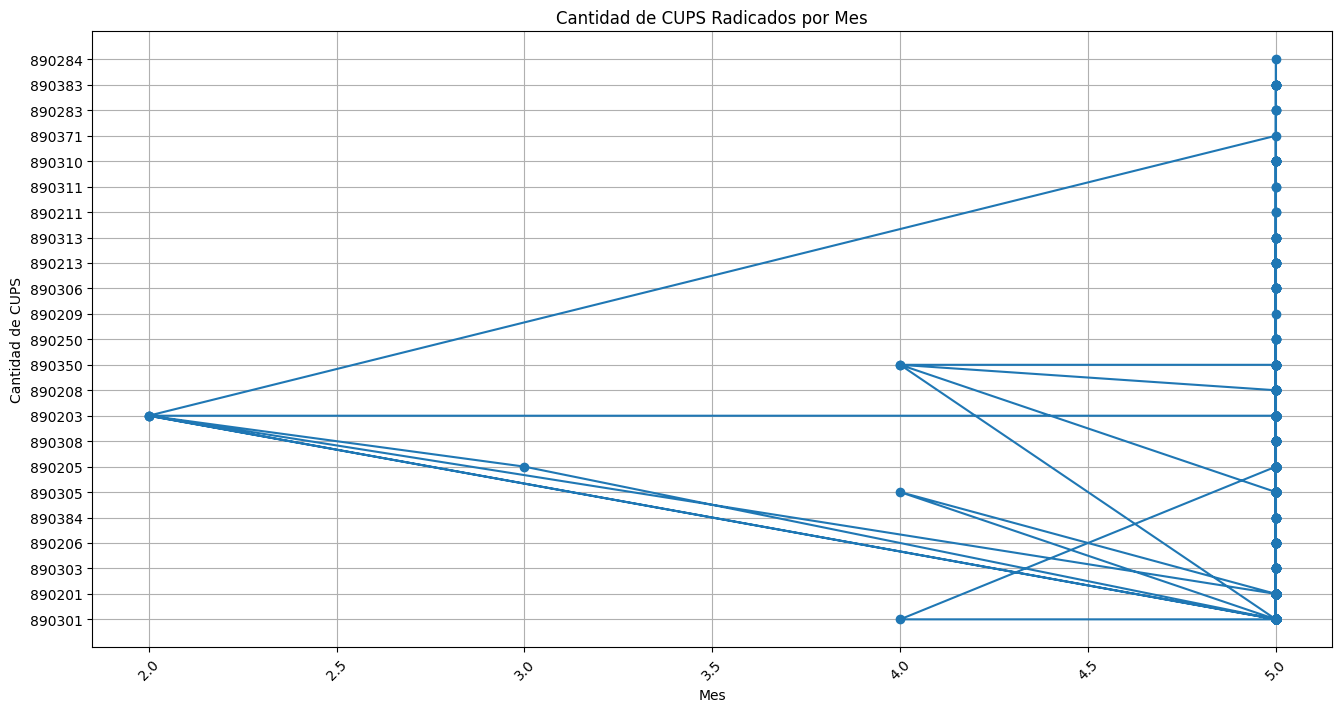

In [63]:
# Generamos la grafica
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plt.plot(
df["MES"],
df["COD CUMS CUPS"],
marker="o"
)
plt.title("Cantidad de CUPS Radicados por Mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de CUPS")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()